# Solving the KdV Equation with Fourier Spectral Method

This notebook demonstrates how to solve the Korteweg-de Vries (KdV) equation using the provided `kdv.py` script and visualizes one of its solutions.

In [8]:
# Import Required Libraries and kdv.py Script
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure the scripts directory is in the path
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

from kdv import kdv_etdrk4, kdv_soliton

## Set Initial Conditions for the KdV Equation

We define the spatial domain, time parameters, and use a single-soliton initial condition.

In [9]:
# Define spatial and time domain, and initial condition
Lx =15.0        # Domain length
N = 256          # Number of spatial grid points
x = np.linspace(0, Lx, N, endpoint=False)

# Soliton parameters
c = 1.0          # Soliton speed/amplitude
x0 = Lx / 3.0    # Initial soliton center

# Initial condition: single soliton
u0 = kdv_soliton(x, c=c, x0=x0)

dt = 0.1        # Time step
Tfinal = 10.0    # Final time
steps = int(np.round(Tfinal / dt))
save_every = 1  # Save every 20 steps

## Solve the KdV Equation Using the Script

We now solve the KdV equation using the ETDRK4 Fourier spectral solver from the script.

In [10]:
# Solve the KdV equation
sol = kdv_etdrk4(
    u0=u0,
    Lx=Lx,
    dt=dt,
    steps=steps,
    save_every=save_every,
    dealias=True,
    M_phi=32,
    progress=True,
)

print(f"Done. Saved {len(sol.t)} snapshots on N={sol.N} grid, dt={sol.dt:g}, Lx={sol.Lx:g}")

[KdV] 10% complete
[KdV] 20% complete
[KdV] 30% complete
[KdV] 40% complete
[KdV] 50% complete
[KdV] 60% complete
[KdV] 70% complete
[KdV] 80% complete
[KdV] 89% complete
[KdV] 99% complete
Done. Saved 101 snapshots on N=256 grid, dt=0.1, Lx=15


## Plot a Solution of the KdV Equation

We plot the initial and final solution to visualize the evolution of the soliton.

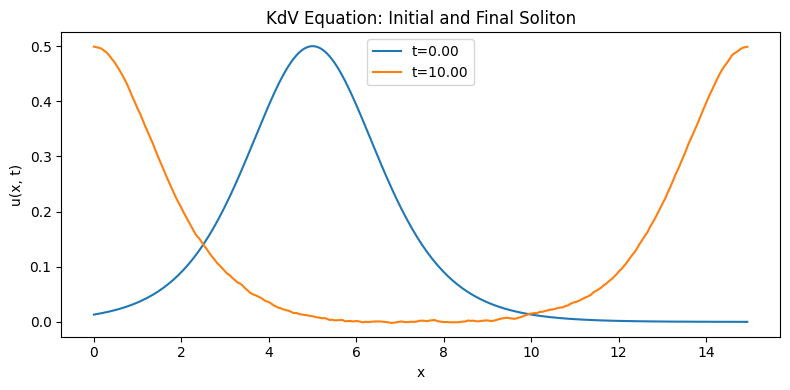

In [11]:
# Plot the initial and final solution
plt.figure(figsize=(8, 4))
plt.plot(sol.x, sol.u[0], label=f"t={sol.t[0]:.2f}")
plt.plot(sol.x, sol.u[-1], label=f"t={sol.t[-1]:.2f}")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("KdV Equation: Initial and Final Soliton")
plt.legend()
plt.tight_layout()
plt.show()

## Sample 100 Random, Periodic, C^3-Smooth Initial Conditions

We generate 100 random periodic initial conditions constructed from a Fourier series with coefficients decaying like 1/k^4 (this ensures C^3 smoothness). Each initial condition is mean-zero and scaled to moderate amplitude. We then run the KdV solver for each sample and save the results to a compressed file.

In [12]:
# Sample 100 trajectories with periodic C^3-smooth initial conditions
import time
rng = np.random.default_rng(123456)
from scipy.interpolate import CubicSpline, make_interp_spline


def random_periodic_c3(x, Lx, Kmax=64, sigma=1.0, rng=None):
    """Construct a periodic, mean-zero function with Fourier coefficients ~ N(0, sigma/k^4).
    That decay ensures the function is C^3 (derivatives up to order 3 are continuous).
    """
    if rng is None:
        rng = np.random.default_rng()
    u = np.zeros_like(x)
    for k in np.random.choice(np.linspace(5,10, dtype=int), Kmax):
        scale = sigma / k**4 if k > 0 else 0.0
        a = rng.normal(0, scale)
        b = rng.normal(0, scale)
        u += a * np.cos(2.0 * np.pi * k * x / Lx) + b * np.sin(2.0 * np.pi * k * x / Lx)
    # mean-zero
    u -= np.mean(u)
    # scale to moderate amplitude
    maxamp = np.max(np.abs(u))
    if maxamp > 0:
        u *= 1.0 / maxamp
    return u

def sample_cs_initial_condition(x, n_points):
    xp = np.linspace(x[0], x[-1], n_points)
    yp = np.random.uniform(0, 1, n_points)
    yp[-1] = yp[0]  # Ensure periodicity for CubicSpline
    cs = make_interp_spline(xp, yp, bc_type='periodic', k=4)
    return cs(x)

# Sampling/run parameters
n_samples = 10
Kmax = 8
sigma = 1
Tfinal_samples = 10.0
dt_samples = 0.1
steps_samples = int(np.round(Tfinal_samples / dt_samples))
save_every_samples = 1
x = np.linspace(0,Lx, N)
# Prepare storage (allocate after first run when we know shape)
results_u = None
times = None
start_time = time.time()

for i in range(n_samples):
    u0_i = sample_cs_initial_condition(x, n_points=8 ) #random_periodic_c3(x, Lx, Kmax, sigma )
    sol_i = kdv_etdrk4(
        u0=u0_i,
        Lx=Lx,
        dt=dt_samples,
        steps=steps_samples,
        save_every=save_every_samples,
        dealias=False,
        M_phi=32,
        progress=False,
        q = -6
    )

    if results_u is None:
        num_saves = sol_i.u.shape[0]
        results_u = np.empty((n_samples, num_saves, sol_i.u.shape[1]), dtype=float)
        times = sol_i.t

    results_u[i] = sol_i.u

    if (i + 1) % 10 == 0 or (i + 1) == n_samples:
        elapsed = time.time() - start_time
        print(f"Completed {i+1}/{n_samples} runs — elapsed {elapsed:.1f}s")

# Save compressed results for later analysis
out_name = "kdv_samples.npz"
np.savez_compressed(out_name, x=sol_i.x, t=times, u=results_u, Lx=Lx)
print(f"Saved samples to {out_name} — total time {time.time()-start_time:.1f}s")

Completed 10/10 runs — elapsed 0.1s
Saved samples to kdv_samples.npz — total time 0.2s


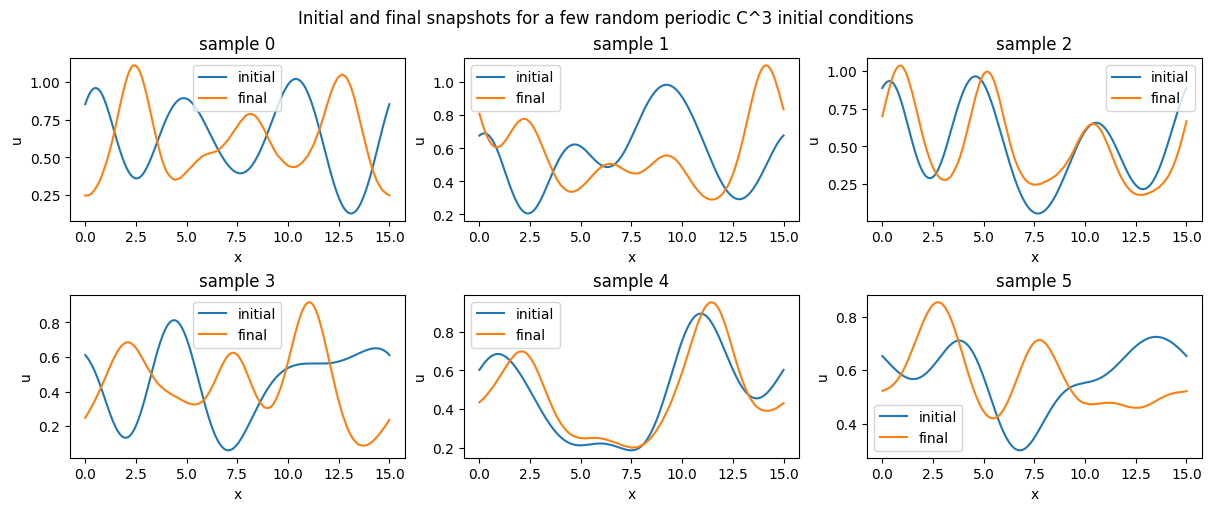

In [13]:
# Quick visualization: show initial and final snapshots for a few samples
import matplotlib.pyplot as plt

n_show = 6
idxs = np.arange(min(n_show, n_samples))
cols = 3
rows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows), constrained_layout=True)
axes = axes.ravel()
for ax_i, idx in zip(axes, idxs):
    ax_i.plot(x, results_u[idx, 0], label='initial')
    ax_i.plot(x, results_u[idx, -1], label='final')
    ax_i.set_title(f'sample {idx}')
    ax_i.set_xlabel('x')
    ax_i.set_ylabel('u')
    ax_i.legend()
# Hide any unused axes
for j in range(len(idxs), len(axes)):
    axes[j].axis('off')

plt.suptitle('Initial and final snapshots for a few random periodic C^3 initial conditions')
plt.show()

In [14]:
# Animate the evolution of the first trajectory
import matplotlib.animation as animation
from IPython.display import HTML

idx = np.random.choice(n_samples)
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot([], [], lw=2)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(np.min(results_u[idx]), np.max(results_u[idx]))
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('KdV Evolution: Animated Trajectory')
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

# Initialization function
def init():
    line.set_data([], [])
    time_text.set_text('')
    return line, time_text

# Animation function
def animate(i):
    line.set_data(x, results_u[idx, i])
    time_text.set_text(f't = {times[i]:.2f}')
    return line, time_text

# Build animation (use blit=False for better compatibility when saving)
ani = animation.FuncAnimation(
    fig, animate, frames=results_u.shape[1], init_func=init,
    blit=False, interval=60, repeat=False,
)

# Close the figure to avoid double-display; render as HTML5 video inline
plt.close(fig)

display(HTML(ani.to_html5_video()))

# Try saving to MP4 (requires ffmpeg) and GIF (pillow). Fail gracefully if writers missing.
out_mp4 = 'kdv_evolution.mp4'
out_gif = 'kdv_evolution.gif'
fps = int(round(1000.0 / 60.0))

try:
    ani.save(out_mp4, writer='ffmpeg', fps=fps)
    print('Saved animation to', out_mp4)
except Exception as e:
    print('MP4 save failed (ffmpeg may be missing):', e)

try:
    ani.save(out_gif, writer='pillow', fps=fps)
    print('Saved animation to', out_gif)
except Exception as e:
    print('GIF save failed (pillow writer may be missing):', e)


Saved animation to kdv_evolution.mp4
Saved animation to kdv_evolution.gif
